In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
import math

df = pd.read_csv('/Volumes/Extreme Pro/DSAN-5200/final-project/T_DB1B_MARKET_CLEAN.csv')   


In [2]:
import matplotlib.pyplot as plt
plt.style.use("theme.mplstyle")

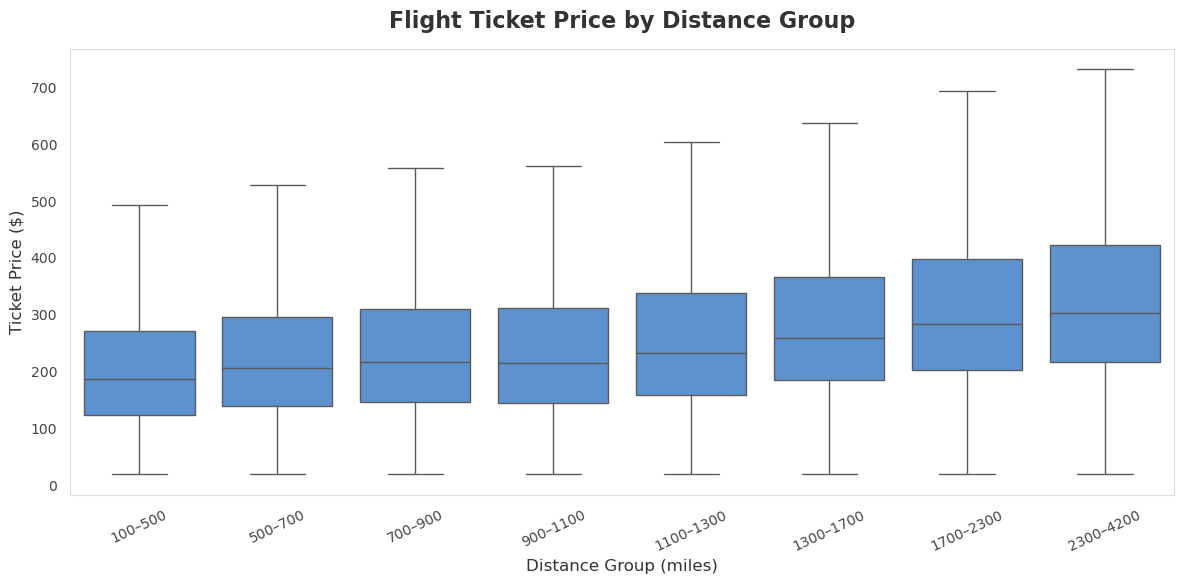

<Figure size 1200x600 with 0 Axes>

In [7]:
import pandas as pd

## sample 50k
df_sample = df.sample(50000, random_state=5200).copy()
df_sample = df_sample[
    (df_sample["MARKET_DISTANCE"] <= df_sample["MARKET_DISTANCE"].quantile(0.99)) &
    (df_sample["MARKET_FARE"] <= df_sample["MARKET_FARE"].quantile(0.99))
]

df_sample["distance_bin"] = pd.qcut(df_sample["MARKET_DISTANCE"], 8)
df_sample["distance_bin"] = df_sample["distance_bin"].apply(
    lambda x: f"{int(round(x.left, -2))}–{int(round(x.right, -2))}"
)

sns.set_theme()
plt.style.use("theme.mplstyle")


sns.boxplot(
    data=df_sample,
    x="distance_bin",
    y="MARKET_FARE",
    showfliers=False,
    color = "#4a91e2"
)

plt.title("Flight Ticket Price by Distance Group", pad=15)
plt.xlabel("Distance Group (miles)")
plt.ylabel("Ticket Price ($)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

plt.savefig('../../report/images/static_viz_1.png')


In [21]:
### EQUAL MILEAGE RANGES 


import numpy as np
import pandas as pd

df_sample = df.sample(50000, random_state=5200).copy()


# Choose bin width, e.g. 500-mile groups
bin_width = 500

# Create clean equal-width bins
min_distance = 0
max_distance = np.ceil(df_sample["MARKET_DISTANCE"].max() / bin_width) * bin_width

bins = np.arange(min_distance, max_distance + bin_width, bin_width)


df_sample["distance_bin"] = pd.cut(
    df_sample["MARKET_DISTANCE"],
    bins=bins,
    include_lowest=True
)

# Optional: clean labels like "0–500", "500–1000"
labels = [f"{int(bins[i]):,}–{int(bins[i+1]):,}" for i in range(len(bins)-1)]

df_sample["distance_bin"] = pd.cut(
    df_sample["MARKET_DISTANCE"],
    bins=bins,
    labels=labels,
    include_lowest=True
)



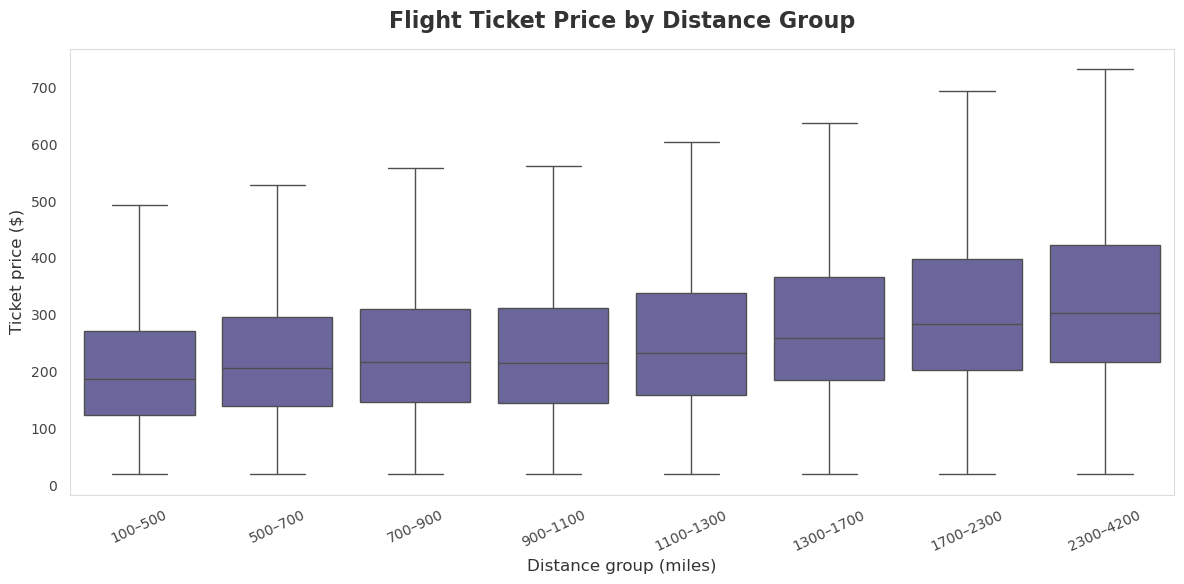

<Figure size 1200x600 with 0 Axes>

In [ ]:
sns.set_theme()
plt.style.use("theme.mplstyle")


sns.boxplot(
    data=df_sample,
    x="distance_bin",
    y="MARKET_FARE",
    showfliers=False,
    color = "#635ea6"
)

plt.title("Flight Ticket Price by Distance Group", pad=15)
plt.xlabel("Distance group (miles)")
plt.ylabel("Ticket price ($)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()



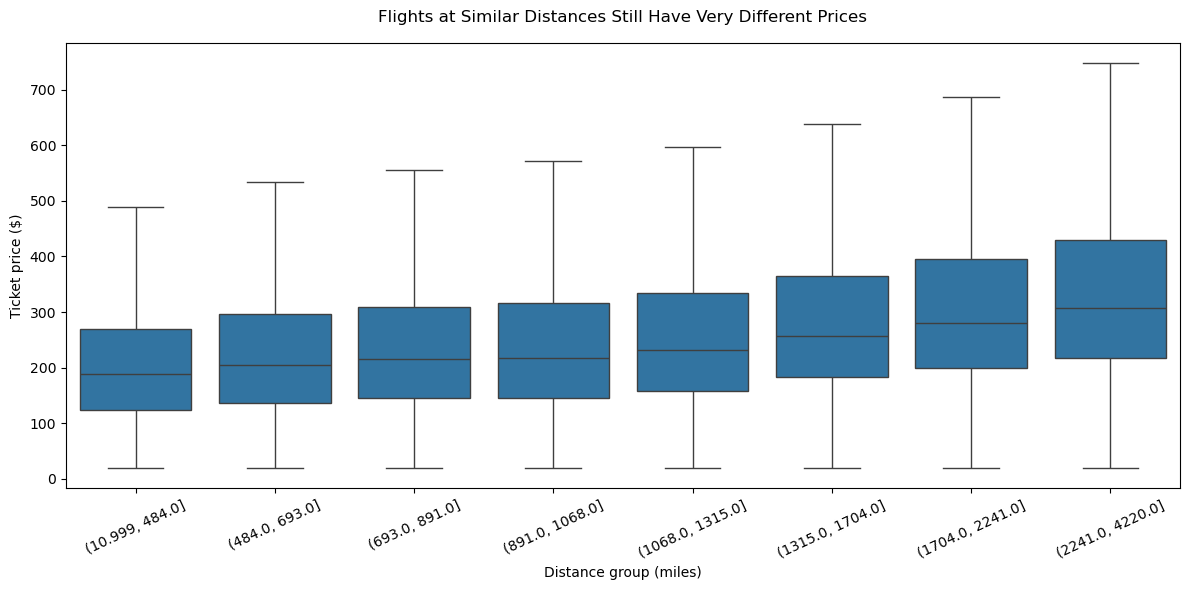

In [ ]:
### FULL DATASET
df = df[
    (df["MARKET_DISTANCE"] <= df["MARKET_DISTANCE"].quantile(0.99)) &
    (df["MARKET_FARE"] <= df["MARKET_FARE"].quantile(0.99))
]

df["distance_bin"] = pd.qcut(df["MARKET_DISTANCE"], 8)



plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="distance_bin",
    y="MARKET_FARE",
    showfliers=False
)

plt.title("Flights at Similar Distances Still Have Very Different Prices", pad=15)
plt.xlabel("Distance group (miles)")
plt.ylabel("Ticket price ($)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

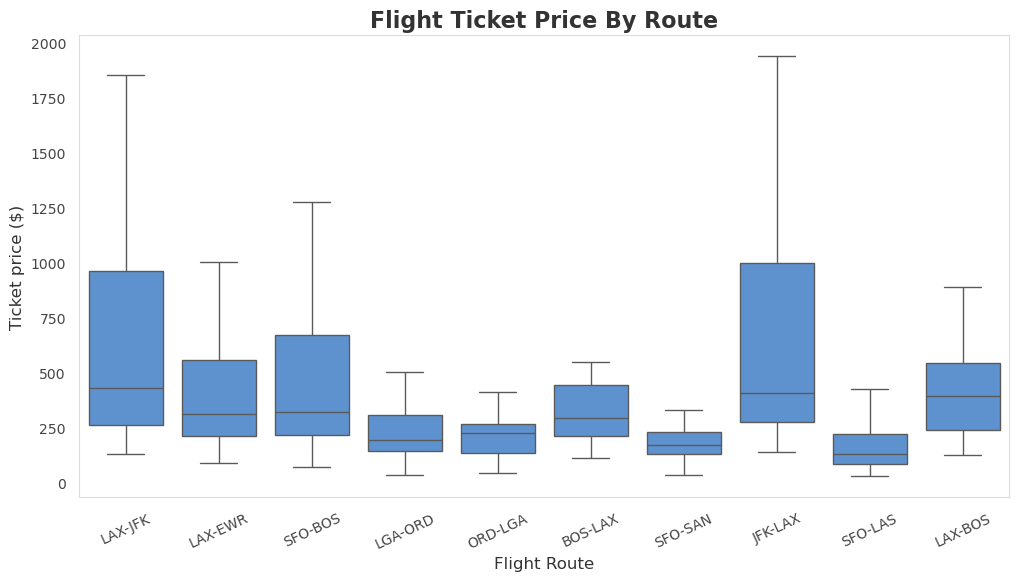

<Figure size 1200x600 with 0 Axes>

In [8]:
df_sample = df.sample(50000, random_state=5200).copy()
df_sample["route"] = df_sample["ORIGIN"] + "-" + df_sample["DEST"]
top_routes = df_sample["route"].value_counts().nlargest(10).index
df_routes = df_sample[df_sample["route"].isin(top_routes)]

sns.set_theme()
plt.style.use("theme.mplstyle")


sns.boxplot(data=df_routes,
            x="route", 
            y="MARKET_FARE", 
            showfliers=False,
            color = "#4a91e2"
            )
plt.xticks(rotation=45)
plt.title("Flight Ticket Price By Route")
plt.xlabel("Flight Route")
plt.ylabel("Ticket price ($)")
plt.xticks(rotation=25)
plt.show()

plt.savefig('../../report/images/static_viz_2.png')
